In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import pandas as pd

df = pd.read_csv("unemployment.csv")

In [4]:
df.head()

,country_name,indicator_name,sex,age_group,age_categories,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Afghanistan,Unemployment rate by sex and age,Female,15-24,Youth,13.340,15.974,18.570,21.137,20.649,20.154,21.228,21.640,30.561,32.200,33.332
1,Afghanistan,Unemployment rate by sex and age,Female,25+,Adults,8.576,9.014,9.463,9.920,11.223,12.587,14.079,14.415,23.818,26.192,28.298
2,Afghanistan,Unemployment rate by sex and age,Female,Under 15,Children,10.306,11.552,12.789,14.017,14.706,15.418,16.783,17.134,26.746,29.193,30.956
3,Afghanistan,Unemployment rate by sex and age,Male,15-24,Youth,9.206,11.502,13.772,16.027,15.199,14.361,14.452,15.099,16.655,18.512,19.770
4,Afghanistan,Unemployment rate by sex and age,Male,25+,Adults,6.463,6.879,7.301,7.728,7.833,7.961,8.732,9.199,11.357,12.327,13.087


In [5]:
df.isnull().sum()

,0
country_name,0
indicator_name,0
sex,0
age_group,0
age_categories,0
2014,0
2015,0
2016,0
2017,0
2018,0


In [6]:
df = df.dropna()

In [7]:
df.isnull().sum()

,0
country_name,0
indicator_name,0
sex,0
age_group,0
age_categories,0
2014,0
2015,0
2016,0
2017,0
2018,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000,1122.000000
mean,11.289801,11.155382,10.991702,10.718752,10.368546,10.174088,11.715309,11.278857,10.215924,9.985181,9.940089
std,11.064594,10.822105,10.611162,10.456346,10.325511,10.109488,11.072823,10.707529,10.103436,9.987778,9.977512
min,0.027000,0.034000,0.038000,0.035000,0.044000,0.036000,0.056000,0.064000,0.067000,0.063000,0.060000
25%,3.926500,3.968000,3.918250,3.739500,3.636750,3.533000,4.304750,4.146250,3.542500,3.477500,3.459750
50%,7.611500,7.448500,7.392500,7.057500,6.649500,6.544000,7.944000,7.440500,6.544500,6.466000,6.364000
75%,14.888750,14.495500,14.231750,13.902000,13.175000,13.157000,15.242000,14.692250,13.272500,12.914500,12.687750
max,74.485000,74.655000,74.720000,75.416000,76.395000,77.173000,83.990000,82.135000,78.776000,78.541000,78.644000


In [10]:
years = ['2014','2015','2016','2017','2018','2019',
         '2020','2021','2022','2023','2024']

average_unemployment = df[years].mean()

print(average_unemployment)

2014    11.289801
2015    11.155382
2016    10.991702
2017    10.718752
2018    10.368546
2019    10.174088
2020    11.715309
2021    11.278857
2022    10.215924
2023     9.985181
2024     9.940089
dtype: float64


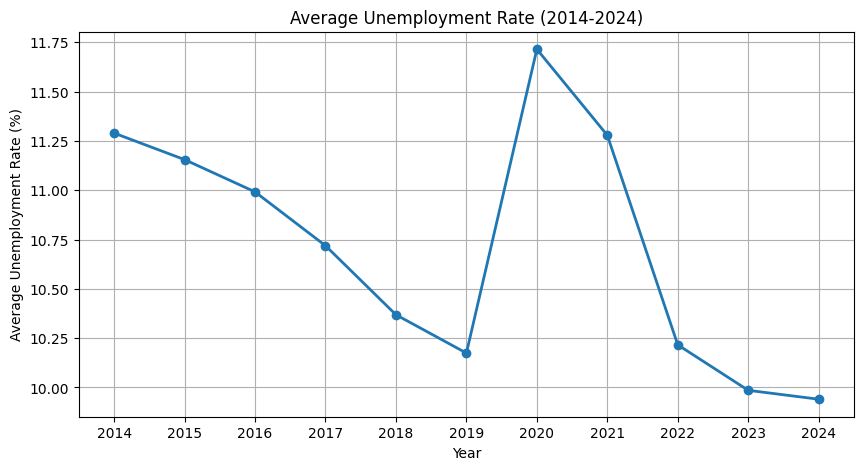

In [14]:
import matplotlib.pyplot as plt

years = ['2014','2015','2016','2017','2018',
         '2019','2020','2021','2022','2023','2024']

average_unemployment = df[years].mean()

plt.figure(figsize=(10,5))

plt.plot(years, average_unemployment,
         marker='o',
         linewidth=2)

plt.title("Average Unemployment Rate (2014-2024)")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate (%)")

plt.grid(True)

plt.show()

In [15]:
import os

os.makedirs("images", exist_ok=True)

In [16]:
plt.savefig("images/unemployment_trend.png")

<Figure size 640x480 with 0 Axes>

In [17]:
gender_analysis = df.groupby("sex")[years].mean()

gender_analysis

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
sex,,,,,,,,,,,
Female,12.400681,12.267995,12.126729,11.910932,11.512537,11.352428,12.977520,12.513572,11.424916,11.137763,11.118121
Male,10.178922,10.042770,9.856676,9.526572,9.224556,8.995749,10.453098,10.044143,9.006932,8.832599,8.762057


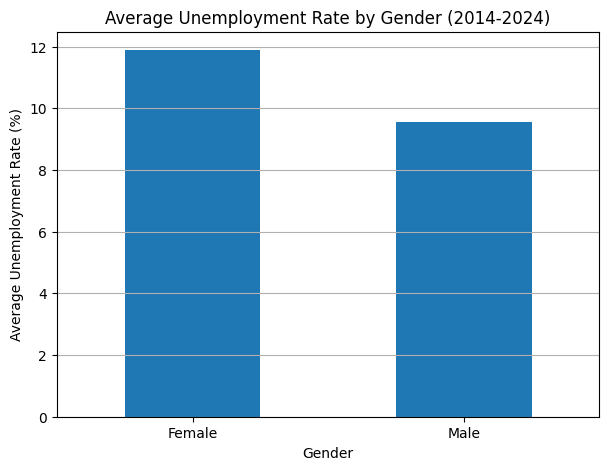

In [18]:
gender_avg = df.groupby("sex")[years].mean().mean(axis=1)

plt.figure(figsize=(7,5))

gender_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Gender (2014-2024)")
plt.xlabel("Gender")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.savefig("images/gender_analysis.png")

plt.show()

In [19]:
age_analysis = df.groupby("age_categories")[years].mean()

age_analysis

,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
age_categories,,,,,,,,,,,
Adults,6.681591,6.615377,6.505725,6.323241,6.084126,5.988904,6.882059,6.750845,6.058430,5.916706,5.872537
Children,8.485832,8.381564,8.239580,7.999594,7.696807,7.552941,8.629516,8.372398,7.543353,7.374644,7.322158
Youth,18.701981,18.469206,18.229802,17.833422,17.324706,16.980420,19.634353,18.713329,17.045989,16.664193,16.625572


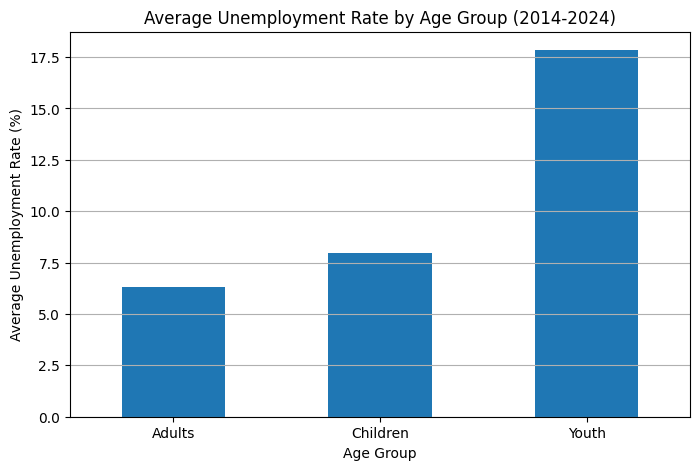

In [20]:
age_avg = df.groupby("age_categories")[years].mean().mean(axis=1)

plt.figure(figsize=(8,5))

age_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Age Group (2014-2024)")
plt.xlabel("Age Group")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.savefig("images/age_analysis.png")

plt.show()

In [21]:
country_analysis = df.groupby("country_name")["2024"].mean()

country_analysis = country_analysis.sort_values(ascending=False)

country_analysis.head(10)

,2024
country_name,
Djibouti,42.623000
South Africa,35.261000
Libya,29.670167
Botswana,29.077667
Sudan,29.032500
Eswatini,28.975833
Iraq,28.067167
Jordan,27.609833
Gabon,26.198000


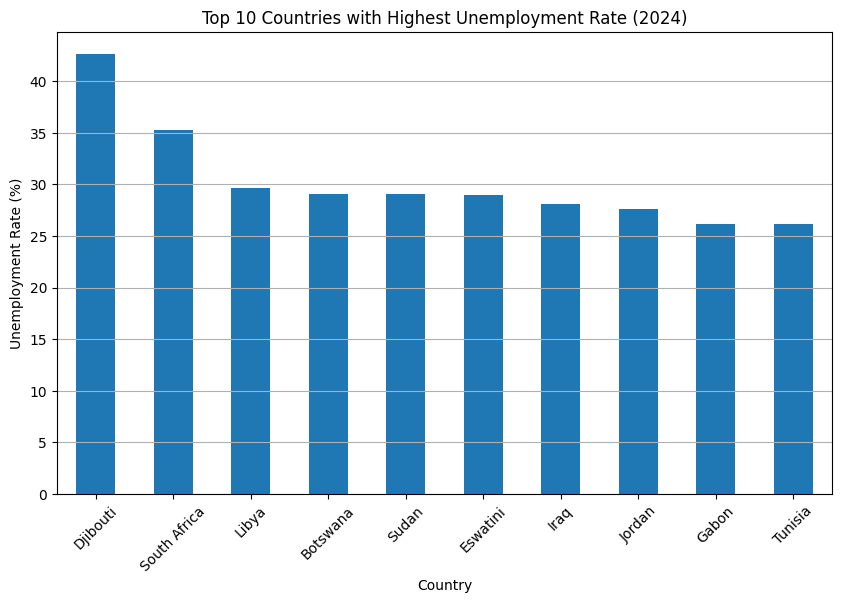

In [22]:
top_countries = country_analysis.head(10)

plt.figure(figsize=(10,6))

top_countries.plot(kind="bar")

plt.title("Top 10 Countries with Highest Unemployment Rate (2024)")
plt.xlabel("Country")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.savefig("images/top10_countries_2024.png")

plt.show()

In [23]:
covid_impact = df.groupby("country_name")[["2019","2020"]].mean()

covid_impact["increase"] = covid_impact["2020"] - covid_impact["2019"]

covid_impact.sort_values("increase", ascending=False).head(10)

,2019,2020,increase
country_name,,,
Panama,9.777167,20.356833,10.579667
Costa Rica,17.082500,23.982000,6.899500
Colombia,13.600333,19.847667,6.247333
Saint Lucia,20.791667,26.830333,6.038667
New Caledonia,17.228833,22.913500,5.684667
Canada,7.079167,12.590333,5.511167
Montenegro,18.153167,23.656333,5.503167
Honduras,7.355500,12.804167,5.448667
Bolivia,4.566500,9.985667,5.419167


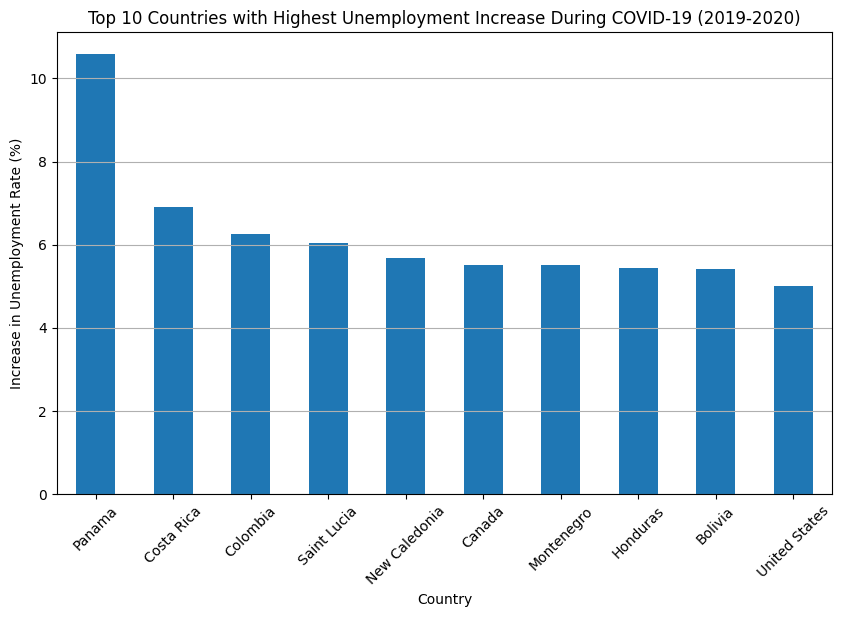

In [24]:
covid_top10 = covid_impact.sort_values("increase", ascending=False).head(10)

plt.figure(figsize=(10,6))

covid_top10["increase"].plot(kind="bar")

plt.title("Top 10 Countries with Highest Unemployment Increase During COVID-19 (2019-2020)")
plt.xlabel("Country")
plt.ylabel("Increase in Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.savefig("images/covid_impact.png")

plt.show()

# Final Insights

## Unemployment Analysis Summary

1. Unemployment trends showed a gradual decline from 2014 to 2019, followed by a significant increase in 2020 due to the COVID-19 pandemic.

2. Gender analysis revealed that female unemployment rates were consistently higher than male unemployment rates throughout the analyzed period.

3. Age group analysis showed that youth unemployment was significantly higher compared to adults and children, indicating challenges faced by young job seekers.

4. Country-level analysis identified Djibouti, South Africa, and Libya among countries with the highest unemployment rates in 2024.

5. COVID-19 impact analysis showed that countries such as Panama, Costa Rica, and Colombia experienced major increases in unemployment during 2020.

6. These findings highlight the importance of employment policies focused on:
   - Youth employment opportunities
   - Gender equality
   - Economic recovery strategies
   - Skill development programs

## Conclusion

This project analyzed global unemployment trends using demographic data.
Python libraries such as Pandas and Matplotlib were used for data cleaning, analysis, and visualization.
The insights obtained help understand how demographic factors and global events influence unemployment patterns.